# Step 1: Import Random Forest and additional utilities

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("master_df.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5219 entries, 0 to 5218
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   IWM_Close   5219 non-null   float64       
 1   QQQ_Close   5219 non-null   float64       
 2   SPY_Close   5219 non-null   float64       
 3   IWM_High    5219 non-null   float64       
 4   QQQ_High    5219 non-null   float64       
 5   SPY_High    5219 non-null   float64       
 6   IWM_Low     5219 non-null   float64       
 7   QQQ_Low     5219 non-null   float64       
 8   SPY_Low     5219 non-null   float64       
 9   IWM_Open    5219 non-null   float64       
 10  QQQ_Open    5219 non-null   float64       
 11  SPY_Open    5219 non-null   float64       
 12  IWM_Volume  5219 non-null   float64       
 13  QQQ_Volume  5219 non-null   float64       
 14  SPY_Volume  5219 non-null   float64       
 15  VIX         5219 non-null   float64       
 16  Date        5219 non-nul

In [3]:
print("DataFrame shape:", df.shape)
print("\nFirst few rows:")
df.head()

DataFrame shape: (5219, 17)

First few rows:


,IWM_Close,QQQ_Close,SPY_Close,IWM_High,QQQ_High,SPY_High,IWM_Low,QQQ_Low,SPY_Low,IWM_Open,QQQ_Open,SPY_Open,IWM_Volume,QQQ_Volume,SPY_Volume,VIX,Date
0,48.436916,33.738789,81.847130,49.422176,34.413565,82.840453,48.179233,33.627749,81.574985,49.335020,34.242735,82.704378,16062600.0,100970900.0,55748000.0,14.08,2005-01-03
1,47.398586,33.123783,80.846992,48.569529,33.943766,82.010405,47.315218,32.927330,80.581653,48.531637,33.883973,81.955975,27450000.0,136623200.0,69167600.0,13.98,2005-01-04
2,46.451256,32.918819,80.289108,47.474410,33.277560,81.132751,46.451256,32.859029,80.282303,47.345570,33.038399,80.785767,29884200.0,127925500.0,65667300.0,14.09,2005-01-05
3,46.697544,32.756512,80.697357,47.140910,33.064005,81.064752,46.401964,32.747972,80.459233,46.739226,32.995675,80.581697,23061200.0,102934600.0,47814700.0,13.58,2005-01-06
4,46.178383,32.927341,80.581665,46.951433,33.200668,81.119149,46.151857,32.636932,80.370750,46.803645,32.935885,80.942254,20906200.0,123104000.0,55847700.0,13.49,2005-01-07


In [4]:
# Momentum features
df['SPY_momentum_5d'] = df['SPY_Close'].pct_change(5)
df['SPY_momentum_10d'] = df['SPY_Close'].pct_change(10)

# VIX features (current level and changes)
df['VIX_current'] = df['VIX']
df['VIX_change_1d'] = df['VIX'].pct_change()
df['VIX_change_5d'] = df['VIX'].pct_change(5)

# Volume features (additional potential predictors)
df['SPY_volume_change_1d'] = df['SPY_Volume'].pct_change()
df['SPY_volume_change_5d'] = df['SPY_Volume'].pct_change(5)

# Target variable: Next day return
df['target_future_return'] = df['SPY_Close'].pct_change().shift(-1)

In [5]:
feature_columns = [
    'SPY_momentum_5d',
    'SPY_momentum_10d',
    'VIX_current',
    'VIX_change_1d',
    'VIX_change_5d',
    'SPY_volume_change_1d',
    'SPY_volume_change_5d'
]
df_clean = df[['Date', 'target_future_return'] + feature_columns].dropna()

# Step 2: Prepare features and target (using your existing feature set)

In [6]:
X = df_clean[feature_columns]
y = df_clean['target_future_return']

print("Feature set for Random Forest:")
for i, feature in enumerate(feature_columns, 1):
    print(f"{i}. {feature}")
print(f"\nData shape: {X.shape}")

Feature set for Random Forest:
1. SPY_momentum_5d
2. SPY_momentum_10d
3. VIX_current
4. VIX_change_1d
5. VIX_change_5d
6. SPY_volume_change_1d
7. SPY_volume_change_5d

Data shape: (5208, 7)


In [7]:
# Step 3: Split data into training and testing sets (time-series aware split)
# For time series, we'll use chronological split
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
dates_train, dates_test = df_clean['Date'].iloc[:split_index], df_clean['Date'].iloc[split_index:]

print(f"Training set: {X_train.shape[0]} samples ({split_ratio*100}%)")
print(f"Testing set: {X_test.shape[0]} samples ({(1-split_ratio)*100}%)")
print(f"Training period: {dates_train.min().date()} to {dates_train.max().date()}")
print(f"Testing period: {dates_test.min().date()} to {dates_test.max().date()}")

Training set: 4166 samples (80.0%)
Testing set: 1042 samples (19.999999999999996%)
Training period: 2005-01-18 to 2021-08-04
Testing period: 2021-08-05 to 2025-09-29


In [8]:
# Step 4: Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Maximum depth of trees
    min_samples_split=20,  # Minimum samples to split a node
    min_samples_leaf=10,   # Minimum samples at a leaf node
    max_features='sqrt',   # Number of features for best split
    random_state=42,       # For reproducibility
    n_jobs=-1             # Use all available cores
)

# Train the model
rf_model.fit(X_train, y_train)
print("Random Forest model training completed!")

Random Forest model training completed!


In [9]:
# Step 5: Make predictions and evaluate model performance
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Calculate performance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("=== Random Forest Performance ===")
print("\nTraining Set:")
print(f"R²: {train_r2:.4f}")
print(f"MSE: {train_mse:.6f}")
print(f"RMSE: {np.sqrt(train_mse):.6f}")
print(f"MAE: {train_mae:.6f}")

print("\nTesting Set:")
print(f"R²: {test_r2:.4f}")
print(f"MSE: {test_mse:.6f}")
print(f"RMSE: {np.sqrt(test_mse):.6f}")
print(f"MAE: {test_mae:.6f}")

=== Random Forest Performance ===

Training Set:
R²: 0.1421
MSE: 0.000129
RMSE: 0.011342
MAE: 0.007254

Testing Set:
R²: 0.0016
MSE: 0.000126
RMSE: 0.011235
MAE: 0.007940


=== Feature Importance ===
                feature  importance
1      SPY_momentum_10d    0.270215
2           VIX_current    0.246163
0       SPY_momentum_5d    0.159437
3         VIX_change_1d    0.099578
4         VIX_change_5d    0.089628
5  SPY_volume_change_1d    0.068690
6  SPY_volume_change_5d    0.066289


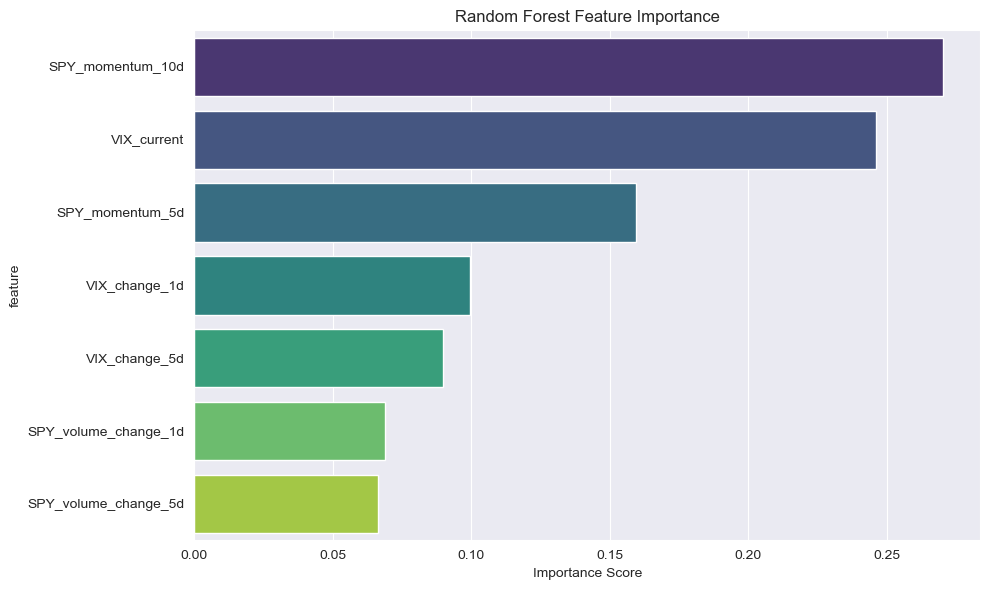

In [10]:
# Step 6: Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== Feature Importance ===")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature',
            palette='viridis', hue='feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Calculating permutation importance...
=== Permutation Importance ===
                feature  importance_mean  importance_std
0       SPY_momentum_5d         0.012755        0.002101
3         VIX_change_1d         0.009188        0.002670
4         VIX_change_5d         0.007892        0.001639
5  SPY_volume_change_1d         0.000811        0.001486
6  SPY_volume_change_5d         0.000678        0.002163
2           VIX_current         0.000494        0.002587
1      SPY_momentum_10d        -0.004969        0.002867


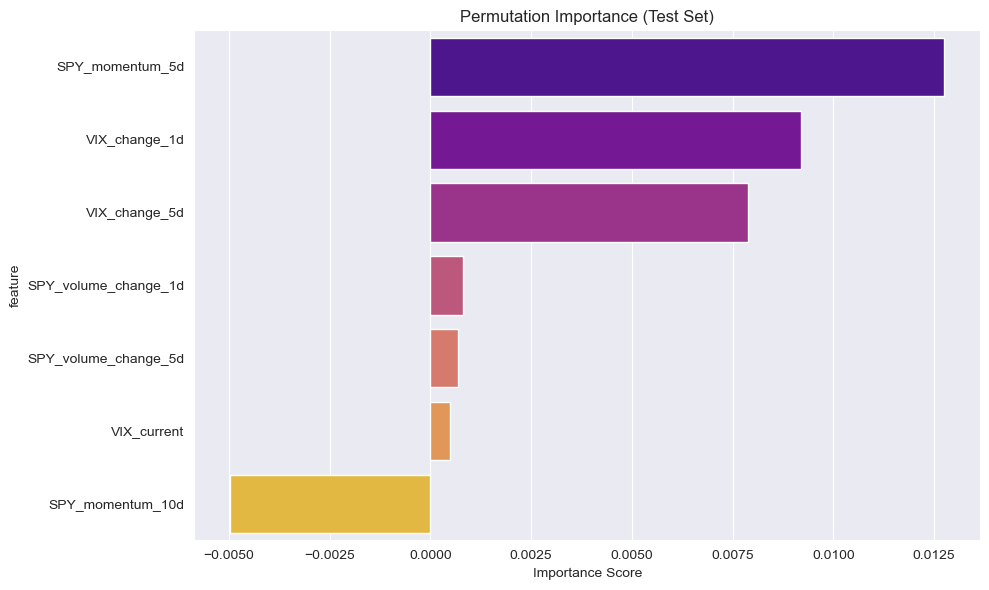

In [11]:
# Step 7: Permutation Importance (more robust measure)
print("Calculating permutation importance...")
perm_importance = permutation_importance(rf_model, X_test, y_test,
                                       n_repeats=10, random_state=42)

perm_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("=== Permutation Importance ===")
print(perm_importance_df)

# Plot permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(data=perm_importance_df, x='importance_mean', y='feature', hue='feature', palette='plasma', legend=False)
plt.title('Permutation Importance (Test Set)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [12]:
# Step 8: Create comprehensive results dataframe
rf_results_df = pd.DataFrame({
    'Date': pd.concat([dates_train, dates_test]),
    'SPY_Close': df.loc[df_clean.index, 'SPY_Close'],
    'actual_future_return': pd.concat([y_train, y_test]),
    'predicted_return': np.concatenate([y_pred_train, y_pred_test]),
    'dataset': ['train'] * len(y_train) + ['test'] * len(y_test)
})

# Add features
for feature in feature_columns:
    rf_results_df[feature] = df_clean[feature]

# Add prediction metrics
rf_results_df['prediction_error'] = rf_results_df['predicted_return'] - rf_results_df['actual_future_return']
rf_results_df['absolute_error'] = np.abs(rf_results_df['prediction_error'])
rf_results_df['trading_signal'] = np.where(rf_results_df['predicted_return'] > 0, 'BUY', 'SELL')
rf_results_df['correct_direction'] = (rf_results_df['actual_future_return'] * rf_results_df['predicted_return']) > 0

print("Random Forest results preview:")
rf_results_df.head(1000)

Random Forest results preview:


,Date,SPY_Close,actual_future_return,predicted_return,dataset,SPY_momentum_5d,SPY_momentum_10d,VIX_current,VIX_change_1d,VIX_change_5d,SPY_volume_change_1d,SPY_volume_change_5d,prediction_error,absolute_error,trading_signal,correct_direction
10,2005-01-18,81.282410,-0.010462,0.000416,train,0.003949,-0.006900,12.47,0.003218,-0.057445,0.365412,0.014646,0.010878,0.010878,BUY,False
11,2005-01-19,80.431999,-0.006091,0.000307,train,0.000338,-0.005133,13.18,0.056937,-0.000758,-0.052495,-0.138207,0.006398,0.006398,BUY,False
12,2005-01-20,79.942108,-0.006128,0.000402,train,-0.009024,-0.004322,13.83,0.049317,0.101115,0.324950,-0.009230,0.006529,0.006529,BUY,False
13,2005-01-21,79.452263,-0.001969,0.000336,train,-0.007142,-0.015429,14.36,0.038322,0.118380,-0.123372,0.137257,0.002305,0.002305,BUY,False
14,2005-01-24,79.295807,0.002831,0.000625,train,-0.014293,-0.015957,14.65,0.020195,0.178600,-0.074707,0.390398,-0.002207,0.002207,BUY,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,2008-12-30,65.433861,0.014275,0.004039,train,0.021939,0.022133,41.63,-0.051708,-0.065754,0.316602,-0.309745,-0.010236,0.010236,BUY,True
1006,2008-12-31,66.367905,0.030142,0.005419,train,0.047354,-0.009876,40.00,-0.039154,-0.111506,0.152927,-0.124706,-0.024723,0.024723,BUY,True
1007,2009-01-02,68.368340,-0.001183,-0.000367,train,0.072698,0.029944,39.19,-0.020250,-0.113549,0.173100,2.666781,0.000816,0.000816,SELL,True
1008,2009-01-05,68.287460,0.006677,-0.002577,train,0.065282,0.048312,39.08,-0.002807,-0.099124,0.056174,2.214619,-0.009254,0.009254,SELL,False


In [13]:
# Step 9: Analyze directional accuracy by dataset
direction_analysis = rf_results_df.groupby('dataset').agg({
    'correct_direction': 'mean',
    'absolute_error': 'mean',
    'actual_future_return': ['mean', 'std']
}).round(4)

print("=== Directional Accuracy Analysis ===")
print(direction_analysis)

train_accuracy = rf_results_df[rf_results_df['dataset'] == 'train']['correct_direction'].mean() * 100
test_accuracy = rf_results_df[rf_results_df['dataset'] == 'test']['correct_direction'].mean() * 100

print(f"\nDirection Prediction Accuracy:")
print(f"Training: {train_accuracy:.2f}%")
print(f"Testing: {test_accuracy:.2f}%")

=== Directional Accuracy Analysis ===
        correct_direction absolute_error actual_future_return        
                     mean           mean                 mean     std
dataset                                                              
test               0.5163         0.0079               0.0005  0.0112
train              0.6097         0.0073               0.0005  0.0122

Direction Prediction Accuracy:
Training: 60.97%
Testing: 51.63%


In [14]:
# Step 11: Save Random Forest results and model info
rf_results_df.to_csv('random_forest_results.csv', index=False)
print("Random Forest results saved to 'random_forest_results.csv'")

# Save feature importance
feature_importance.to_csv('random_forest_feature_importance.csv', index=False)
perm_importance_df.to_csv('random_forest_permutation_importance.csv', index=False)

# Save model summary
with open('random_forest_model_summary.txt', 'w') as f:
    f.write("Random Forest Model Summary\n")
    f.write("==========================\n\n")
    f.write(f"Training R²: {train_r2:.4f}\n")
    f.write(f"Testing R²: {test_r2:.4f}\n")
    f.write(f"Training Direction Accuracy: {train_accuracy:.2f}%\n")
    f.write(f"Testing Direction Accuracy: {test_accuracy:.2f}%\n")
    f.write("\nFeature Importance:\n")
    for _, row in feature_importance.iterrows():
        f.write(f"{row['feature']}: {row['importance']:.4f}\n")

print("Model artifacts saved successfully!")

Random Forest results saved to 'random_forest_results.csv'
Model artifacts saved successfully!


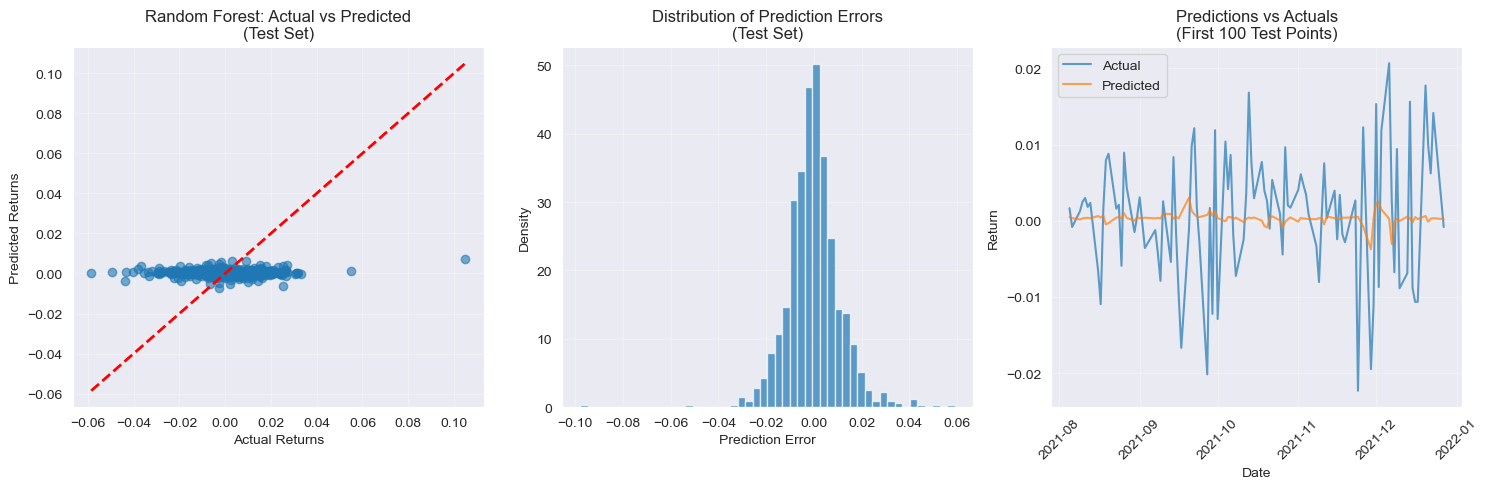

In [15]:
# Step 12: Visualization - Actual vs Predicted (Test Set)
test_results = rf_results_df[rf_results_df['dataset'] == 'test']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(test_results['actual_future_return'], test_results['predicted_return'], alpha=0.6)
plt.plot([test_results['actual_future_return'].min(), test_results['actual_future_return'].max()],
         [test_results['actual_future_return'].min(), test_results['actual_future_return'].max()],
         'r--', lw=2)
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Random Forest: Actual vs Predicted\n(Test Set)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(test_results['prediction_error'], bins=50, alpha=0.7, density=True)
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.title('Distribution of Prediction Errors\n(Test Set)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Time series of predictions vs actuals (first 100 points for clarity)
plt.plot(test_results['Date'].iloc[:100], test_results['actual_future_return'].iloc[:100],
         label='Actual', alpha=0.7)
plt.plot(test_results['Date'].iloc[:100], test_results['predicted_return'].iloc[:100],
         label='Predicted', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('Predictions vs Actuals\n(First 100 Test Points)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()